In [1]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import os
import numpy as np
from sklearn.decomposition import PCA

## Load data

In [2]:
# --- Load data ---
mlst_train_df = pd.read_csv('../assets/mlst_train_set.csv')
mlst_test_df = pd.read_csv('../assets/mlst_test_set.csv')
mlst_val_df = pd.read_csv('../assets/mlst_val_set.csv')

serotype_train_df = pd.read_csv('../assets/serotype_train_set.csv')
serotype_test_df = pd.read_csv('../assets/serotype_test_set.csv')
serotype_val_df = pd.read_csv('../assets/serotype_val_set.csv')

subspecies_train_df = pd.read_csv('../assets/subspecies_train_set.csv')
subspecies_test_df = pd.read_csv('../assets/subspecies_test_set.csv')
subspecies_val_df = pd.read_csv('../assets/subspecies_val_set.csv')

kmc5_arrays = os.path.expanduser('~/PROJECTS/GaTech/FCGR_classifier/salmonella_kmc5_arrays/')
kmc7_arrays = os.path.expanduser('~/PROJECTS/GaTech/FCGR_classifier/salmonella_kmc7_arrays/')

def load_kmer_arrays(df, array_dir, suffix):
    arrays = []
    labels = []
    for idx, row in df.iterrows():
        sample_id = row[0]
        label = row[1]
        array_path = os.path.join(array_dir, f"{sample_id}{suffix}.npy")
        if os.path.exists(array_path):
            array = np.load(array_path).flatten()
            arrays.append(array)
            labels.append(label)
        else:
            print(f"Warning: Array file {array_path} not found.")
    return np.array(arrays), np.array(labels)

# MLST
X_train_mlst_5, y_train_mlst_5 = load_kmer_arrays(mlst_train_df, kmc5_arrays, '_k5_k5')
X_val_mlst_5, y_val_mlst_5 = load_kmer_arrays(mlst_val_df, kmc5_arrays, '_k5_k5')
X_test_mlst_5, y_test_mlst_5 = load_kmer_arrays(mlst_test_df, kmc5_arrays, '_k5_k5')

X_train_mlst_7, y_train_mlst_7 = load_kmer_arrays(mlst_train_df, kmc7_arrays, '_k7_k7')
X_val_mlst_7, y_val_mlst_7 = load_kmer_arrays(mlst_val_df, kmc7_arrays, '_k7_k7')
X_test_mlst_7, y_test_mlst_7 = load_kmer_arrays(mlst_test_df, kmc7_arrays, '_k7_k7')

# Serotype
X_train_sero_5, y_train_sero_5 = load_kmer_arrays(serotype_train_df, kmc5_arrays, '_k5_k5')
X_val_sero_5, y_val_sero_5 = load_kmer_arrays(serotype_val_df, kmc5_arrays, '_k5_k5')
X_test_sero_5, y_test_sero_5 = load_kmer_arrays(serotype_test_df, kmc5_arrays, '_k5_k5')

X_train_sero_7, y_train_sero_7 = load_kmer_arrays(serotype_train_df, kmc7_arrays, '_k7_k7')
X_val_sero_7, y_val_sero_7 = load_kmer_arrays(serotype_val_df, kmc7_arrays, '_k7_k7')
X_test_sero_7, y_test_sero_7 = load_kmer_arrays(serotype_test_df, kmc7_arrays, '_k7_k7')

# Subspecies
X_train_sub_5, y_train_sub_5 = load_kmer_arrays(subspecies_train_df, kmc5_arrays, '_k5_k5')
X_val_sub_5, y_val_sub_5 = load_kmer_arrays(subspecies_val_df, kmc5_arrays, '_k5_k5')
X_test_sub_5, y_test_sub_5 = load_kmer_arrays(subspecies_test_df, kmc5_arrays, '_k5_k5')

X_train_sub_7, y_train_sub_7 = load_kmer_arrays(subspecies_train_df, kmc7_arrays, '_k7_k7')
X_val_sub_7, y_val_sub_7 = load_kmer_arrays(subspecies_val_df, kmc7_arrays, '_k7_k7')
X_test_sub_7, y_test_sub_7 = load_kmer_arrays(subspecies_test_df, kmc7_arrays, '_k7_k7')

/scicomp/scratch/rqu4/tmp/ipykernel_637176/1047022088.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_id = row[0]
/scicomp/scratch/rqu4/tmp/ipykernel_637176/1047022088.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[1]


## Define model

In [3]:
# --- Function to train and evaluate SVM ---
def train_svm(X_train, y_train, X_val, y_val, X_test, y_test):
    # Create pipeline with standard scaler and SVM
    model = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=42))
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Validation predictions
    y_val_pred = model.predict(X_val)
    print("Validation Set Classification Report:")
    print(classification_report(y_val, y_val_pred))
    
    f1_val_macro = f1_score(y_val, y_val_pred, average='macro')
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_test_pred))
    
    f1_test_macro = f1_score(y_test, y_test_pred, average='macro')
    
    return model, f1_val_macro, f1_test_macro

## Run model on kmer=5

In [4]:
# --- Run SVM for k=5 ---
results_svm = []

# --- MLST ---
mlst_model_5, f1_val, f1_test = train_svm(X_train_mlst_5, y_train_mlst_5,
                                           X_val_mlst_5, y_val_mlst_5,
                                           X_test_mlst_5, y_test_mlst_5)
results_svm.append({"dataset": "MLST", "kmer": 5, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

# --- Serotype ---
serotype_model_5, f1_val, f1_test = train_svm(X_train_sero_5, y_train_sero_5,
                                              X_val_sero_5, y_val_sero_5,
                                              X_test_sero_5, y_test_sero_5)
results_svm.append({"dataset": "Serotype", "kmer": 5, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

# --- Subspecies ---
subspecies_model_5, f1_val, f1_test = train_svm(X_train_sub_5, y_train_sub_5,
                                                X_val_sub_5, y_val_sub_5,
                                                X_test_sub_5, y_test_sub_5)
results_svm.append({"dataset": "Subspecies", "kmer": 5, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

# Save results for k=5
results_svm_df = pd.DataFrame(results_svm)
results_svm_df.to_csv("../results/svm_macro_f1_results_k5.csv", index=False)
print("Complete")

Validation Set Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       0.71      0.62      0.67        16
          13       1.00      1.00      1.00        16
          14       1.00      1.00      1.00        16
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        16
          17       0.84      1.00      0.91        16
          18       1.00      1.00      1.00        16
          19       1.00      0.88      0.93        16
          20       0.89      1.00      0.94        16
          22       0.94      1.00      0.97        16
          23       0.94      0.94      0.94        16
          24       1.00      0.94      0.97

## Run model on kmer=7

In [5]:
# --- Run SVM for k=7 ---
results_svm_k7 = []

# MLST
_, f1_val, f1_test = train_svm(X_train_mlst_7, y_train_mlst_7,
                               X_val_mlst_7, y_val_mlst_7,
                               X_test_mlst_7, y_test_mlst_7)
results_svm_k7.append({"dataset": "MLST", "kmer": 7, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

# Serotype
_, f1_val, f1_test = train_svm(X_train_sero_7, y_train_sero_7,
                               X_val_sero_7, y_val_sero_7,
                               X_test_sero_7, y_test_sero_7)
results_svm_k7.append({"dataset": "Serotype", "kmer": 7, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

# Subspecies
_, f1_val, f1_test = train_svm(X_train_sub_7, y_train_sub_7,
                               X_val_sub_7, y_val_sub_7,
                               X_test_sub_7, y_test_sub_7)
results_svm_k7.append({"dataset": "Subspecies", "kmer": 7, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

# Save results for k=7
results_svm_k7_df = pd.DataFrame(results_svm_k7)
results_svm_k7_df.to_csv("../results/svm_macro_f1_results_k7.csv", index=False)
print("Complete")

Validation Set Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       0.94      0.94      0.94        16
          13       1.00      1.00      1.00        16
          14       1.00      1.00      1.00        16
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        16
          17       1.00      1.00      1.00        16
          18       1.00      1.00      1.00        16
          19       1.00      0.94      0.97        16
          20       1.00      1.00      1.00        16
          22       1.00      1.00      1.00        16
          23       1.00      1.00      1.00        16
          24       1.00      1.00      1.00

# SHAP Visualization

In [4]:
# Serotype svm
model, f1_val, f1_test = train_svm(X_train_sero_7, y_train_sero_7,
                               X_val_sero_7, y_val_sero_7,
                               X_test_sero_7, y_test_sero_7)
results_svm_k7.append({"dataset": "Serotype", "kmer": 7, "f1_val_macro": f1_val, "f1_test_macro": f1_test})

Validation Set Classification Report:
                  precision    recall  f1-score   support

           Abony       1.00      1.00      1.00        16
        Adelaide       1.00      0.94      0.97        16
           Agama       1.00      1.00      1.00        16
          Agbeni       1.00      1.00      1.00        16
           Agona       1.00      1.00      1.00        16
         Alachua       1.00      1.00      1.00        16
          Altona       1.00      1.00      1.00        16
       Amsterdam       1.00      1.00      1.00        16
          Anatum       1.00      1.00      1.00        16
         Baildon       0.83      0.94      0.88        16
        Bareilly       1.00      1.00      1.00        16
           Berta       1.00      1.00      1.00        16
        Blockley       1.00      1.00      1.00        16
Bovismorbificans       1.00      1.00      1.00        16
      Braenderup       1.00      1.00      1.00        16
     Brandenburg       1.00      

NameError: name 'results_svm_k7' is not defined

In [5]:
svc = model.named_steps["svc"]
scaler = model.named_steps["standardscaler"]
coef_matrix = svc.coef_

# collapse multiclass → single vector
coef_avg = np.mean(np.abs(coef_matrix), axis=0)

print("Collapsed coefficient vector shape:", coef_avg.shape)

# Convert SVM coefficients to original FCGR scale
coef_orig = coef_avg / scaler.scale_

print("coef_orig shape:", coef_orig.shape)

k = 7
dim = 2**k   # 128

coef_grid = coef_orig.reshape(dim, dim)

coef_norm = coef_grid - coef_grid.min()
coef_norm /= coef_norm.max()

Collapsed coefficient vector shape: (16384,)
coef_orig shape: (16384,)


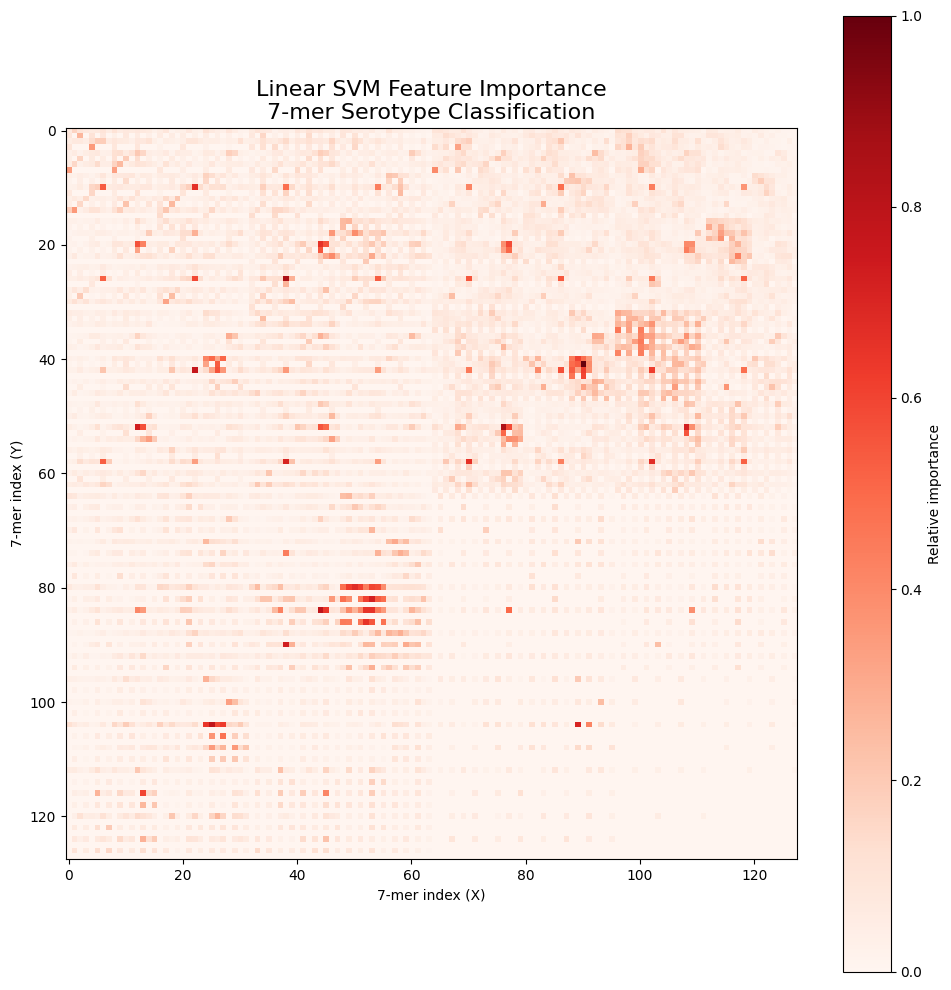

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(coef_norm, cmap="Reds", interpolation="nearest")
plt.title("Linear SVM Feature Importance\n7-mer Serotype Classification", fontsize=16)
plt.colorbar(label="Relative importance")
plt.xlabel("7-mer index (X)")
plt.ylabel("7-mer index (Y)")
plt.tight_layout()
# SAVE TO THE SPECIFIED PATH
save_path = "../figures/SVM_class_SHAP.png"
plt.savefig(save_path, dpi=300)
plt.show()